# Plotting the nucleation mappings: 

This Notebook produces the following plot:

- Figure 7

In [36]:
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from cartopy.feature import ShapelyFeature
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import rasterio
from rasterio.plot import show
from datetime import datetime, timedelta
import matplotlib.path as mpath
from cartopy.geodesic import Geodesic
import shapely.geometry as sgeom
import cartopy
import glob
import cmocean
import matplotlib as mpl
from pathlib import Path

In [ ]:
inpath_processed_hysplit_dfs="E:\\HYSPLIT\\processed\\"
savepath_GR_nuc_site_data=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\back_trajectories_data\GR_nuc_site_data'

loadpath_NPF_for_hsplit=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\GR_dfs'

In [37]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [3]:
def circle_for_polar_map_zep(axes, ZEP_lon=11.888):
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, -ZEP_lon/360], .8
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    axes.set_boundary(circle, transform=axes.transAxes)

In [4]:
path = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\event_times'

filename='events_start_and_end_times_checked.xlsx' 

df_NPF_plusgrowth = pd.read_excel(path+'\\'+filename, index_col=0, parse_dates=True)
df_NPF_plusgrowth.index.name = 'event'

df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)

df_NPF_plusgrowth['start_event'] = df_NPF_plusgrowth['start_event']

event_date='2022-04-18'
df_NPF_plusgrowth[df_NPF_plusgrowth['start_date'] == str(event_date)]

,start_event,end_event,event_class,comments,start_date,end_date
event,,,,,,
2022-04-18,2022-04-18 06:25:00,2022-04-19 03:00:00,Class II,NaN,2022-04-18,2022-04-19


In [ ]:
method_name='rate'
df_NPF_for_hsplit = pd.read_csv(loadpath_NPF_for_hsplit+'\\'+'GR_'+str(method_name)+'.dat',
    index_col=0,parse_dates=True)

In [6]:
df_NPF_for_hsplit.head(2)

,diameters,date,slope,duration,starttime,startdate,endtime,datetime,ordinal,hour_ordinal,hour_in_day,minute_in_day,hour
datetimes,,,,,,,,,,,,,
2022-06-14 03:30:00,3.770083e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:30:00,738320,0,3,30,3.50
2022-06-14 03:45:00,3.934428e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:45:00,738320,0,3,45,3.75


In [7]:
def get_endgrowth_time(df_NPF_for_hsplit, event_date):
    max_diameter = df_NPF_for_hsplit[df_NPF_for_hsplit['date'] == str(event_date)].diameters.max()
    print("max diameter:"+str(max_diameter))
    df_event = df_NPF_for_hsplit[df_NPF_for_hsplit['date'] == str(event_date)].copy()
    growth_endtime = df_event[df_event['diameters'] == max_diameter].index[0]
    return growth_endtime

In [8]:
def append_growth_endtimes_to_NPF_plusgrowth(df_NPF_plusgrowth, df_NPF_for_hsplit):
    df_NPF_plusgrowth['growth_end'] = pd.NaT
    for event_datetime in df_NPF_plusgrowth.index:   
        print(event_datetime) 
        event_date = event_datetime.date()
        print("event: "+str(event_date))        
        try:
            growth_end = get_endgrowth_time(df_NPF_for_hsplit, event_date)
            print("growth end time"+str(growth_end))
        except:
            growth_end = np.nan
            pass
        df_NPF_plusgrowth.loc[df_NPF_plusgrowth.index == str(event_datetime), 'growth_end'] = growth_end
    return df_NPF_plusgrowth

In [9]:
df_NPF_plusgrowth = append_growth_endtimes_to_NPF_plusgrowth(df_NPF_plusgrowth, df_NPF_for_hsplit)

2022-04-17 00:00:00
event: 2022-04-17
max diameter:nan
2022-04-18 00:00:00
event: 2022-04-18
max diameter:1.5605069729058045e-08
growth end time2022-04-18 17:00:00
2022-04-21 00:00:00
event: 2022-04-21
max diameter:1.211460129796652e-08
growth end time2022-04-21 14:00:00
2022-04-23 00:00:00
event: 2022-04-23
max diameter:2.1146260789111593e-08
growth end time2022-04-23 18:00:00
2022-04-24 00:00:00
event: 2022-04-24
max diameter:9.72916236782403e-09
growth end time2022-04-24 21:00:00
2022-04-28 00:00:00
event: 2022-04-28
max diameter:9.4862166397304e-09
growth end time2022-04-28 13:00:00
2022-04-29 00:00:00
event: 2022-04-29
max diameter:3.0885524823714266e-08
growth end time2022-04-30 05:00:00
NaT
event: NaT
max diameter:nan
2022-05-02 00:00:00
event: 2022-05-02
max diameter:2.0283752496134923e-08
growth end time2022-05-02 19:00:00
2022-05-03 00:00:00
event: 2022-05-03
max diameter:1.7146893846104186e-08
growth end time2022-05-03 19:00:00
2022-05-04 00:00:00
event: 2022-05-04
max diame

In [10]:
def hour_rounder(t):
    # Rounds to nearest hour by adding a timedelta hour if minute >= 30
    return (t.replace(second=0, microsecond=0, minute=0, hour=t.hour)
               +timedelta(hours=t.minute//30))

In [11]:
df_NPF_plusgrowth[['start_event', 'growth_end']] = df_NPF_plusgrowth[['start_event', 'growth_end']].dropna(how='any')
df_NPF_plusgrowth = df_NPF_plusgrowth[df_NPF_plusgrowth['start_event'].notna()]
df_NPF_plusgrowth = df_NPF_plusgrowth[df_NPF_plusgrowth['growth_end'].notna()]

df_NPF_plusgrowth['start_event'] = df_NPF_plusgrowth['start_event'].apply(hour_rounder)
df_NPF_plusgrowth['growth_end'] = df_NPF_plusgrowth['growth_end'].apply(hour_rounder)

df_NPF_plusgrowth['duration'] = df_NPF_plusgrowth['growth_end']-df_NPF_plusgrowth['start_event']
df_NPF_plusgrowth['duration'] = df_NPF_plusgrowth['duration'].dt.seconds//3600

In [12]:
def create_HYSPLIT_name_from_list(list_indexes):
    """use the list of indexes and alter it for the format of HYSPLIT"""
    list_strings_indexes = [str(x) for x in list_indexes]
    list_strings_indexes = [x.replace('-','') for x in list_strings_indexes]
    list_strings_indexes = [x.replace(':','') for x in list_strings_indexes]
    list_strings_indexes = [x[:11] for x in list_strings_indexes]
    list_strings_indexes = [x.replace(' ','_') for x in list_strings_indexes]
    return list_strings_indexes

def list_files(year, inpath_processed_hysplit_dfs):
    """Find the a list of all the HYSPLIT files for a particular year"""
    list_of_files = glob.glob(inpath_processed_hysplit_dfs+str(year)+"\\"+'*')    
    return list_of_files

def find_matching_files(list_of_HYSPLIT_files, HYSPLIT_names):
    """observation indexes we want to match with the list of HYSPLIT files"""
    matching_list_of_back_traj_files = [s for s in list_of_HYSPLIT_files if any(xs in s for xs in HYSPLIT_names)]
    print("Matching files from observational data & HYSPLIT: "+str(len(matching_list_of_back_traj_files)))
    return matching_list_of_back_traj_files

def create_traj_dictionary_using_matching_files(matching_list_of_back_traj_files, select_for_mixed_layer=True, traj_length=241,
                                                format_data='.pickle'):
    """an arrival time which maps to the trajectory dataset"""
    if select_for_mixed_layer == True:  
        print("mixed layer selected")
    trajs_dictionary = {}
    for traj_i in matching_list_of_back_traj_files: #each loaded traj_ds is quite long (a full year), so neetraj_ds to be separated  
        #print(traj_i)
        try:
            if format_data == '.dat':
                traj_ds = pd.read_csv(traj_i, parse_dates=['DateTime'], index_col=0) #cut the HYSPLIT using the index occurance of time_step = 0
            if format_data == '.pickle':
                print("file: "+str(traj_i))
                try:
                    traj_ds = pd.read_pickle(traj_i)
                except EOFError:                    
                    break
                traj_ds.index = pd.to_datetime(traj_ds.index)            
            arrival_time_of_traj = str(traj_ds.index[0])
            number_of_trajs = len(traj_ds.index.unique())          
            traj_ds = traj_ds[traj_ds['time_step'] > (traj_length)*(-1)]
            #traj_ds = traj_ds.iloc[:int(traj_length)*int(number_of_trajs),:]
            #print("arrival time: "+str(arrival_time_of_traj))            
            if select_for_mixed_layer == True:               
                traj_ds = traj_ds[traj_ds['MIXDEPTH'] >= traj_ds['altitude']] #select for mixed-layer
            if len(traj_ds) > 0:             
                trajs_dictionary[str(arrival_time_of_traj)] = traj_ds 
        except IndexError:
            print("Index Error - end")
    trajs_dictionary
    return trajs_dictionary

In [13]:
def produce_traj_dict_for_time_range(year, time_range, 
                                     inpath_processed_hysplit_dfs="G:\\HYSPLIT\\processed\\",
                               traj_length=5*24, select_for_mixed_layer=True):   
    HYSPLIT_names_obs = create_HYSPLIT_name_from_list(time_range) #for whole period    
    list_of_HYSPLIT_files = list_files(year=year, 
                                              inpath_processed_hysplit_dfs=inpath_processed_hysplit_dfs)
    matching_list_of_back_traj_files = find_matching_files(list_of_HYSPLIT_files, HYSPLIT_names_obs)
    trajs_dictionary = create_traj_dictionary_using_matching_files(matching_list_of_back_traj_files, 
                                                                          select_for_mixed_layer=select_for_mixed_layer, 
                                                                          traj_length=traj_length, format_data='.pickle')
    return trajs_dictionary

def produce_df_from_dict_of_dfs_only_keys(dictionary):
    final_df = pd.DataFrame()
    for key, value in dictionary.items():
        df = value
        if len(df) > 0:
            final_df = pd.concat([df, final_df], axis=0)
    return final_df

In [14]:
def append_hysplit_date_NPF_dataset(df_NPF_plusgrowth, inpath_processed_hysplit_dfs):
    DFs = []
    for date in df_NPF_plusgrowth.index:
        print(date)
        start = df_NPF_plusgrowth[df_NPF_plusgrowth.index == date].start_event.iloc[0]
        end = df_NPF_plusgrowth[df_NPF_plusgrowth.index == date].growth_end.iloc[0]
        year = start.year
        time_range = pd.date_range(start,end,freq='1h')
        duration = df_NPF_plusgrowth[df_NPF_plusgrowth.index == date].duration.iloc[0]
        trajs_dictionary = produce_traj_dict_for_time_range(year, time_range, 
                                                        inpath_processed_hysplit_dfs,
                                                        traj_length=duration, 
                                                        select_for_mixed_layer=True)  
        df_ = produce_df_from_dict_of_dfs_only_keys(trajs_dictionary)
        DFs.append(df_)
    df_appended_timestamps = pd.concat(DFs)
    df_appended_timestamps['obs'] = np.nan
    return df_appended_timestamps

In [15]:
df_appended_timestamps = append_hysplit_date_NPF_dataset(df_NPF_plusgrowth, inpath_processed_hysplit_dfs)

2022-04-18 00:00:00
Matching files from observational data & HYSPLIT: 12
mixed layer selected
file: E:\HYSPLIT\processed\2022\20220418_06.pickle
file: E:\HYSPLIT\processed\2022\20220418_07.pickle
file: E:\HYSPLIT\processed\2022\20220418_08.pickle
file: E:\HYSPLIT\processed\2022\20220418_09.pickle
file: E:\HYSPLIT\processed\2022\20220418_10.pickle
file: E:\HYSPLIT\processed\2022\20220418_11.pickle
file: E:\HYSPLIT\processed\2022\20220418_12.pickle
file: E:\HYSPLIT\processed\2022\20220418_13.pickle
file: E:\HYSPLIT\processed\2022\20220418_14.pickle
file: E:\HYSPLIT\processed\2022\20220418_15.pickle
file: E:\HYSPLIT\processed\2022\20220418_16.pickle
file: E:\HYSPLIT\processed\2022\20220418_17.pickle
2022-04-21 00:00:00
Matching files from observational data & HYSPLIT: 9
mixed layer selected
file: E:\HYSPLIT\processed\2022\20220421_06.pickle
file: E:\HYSPLIT\processed\2022\20220421_07.pickle
file: E:\HYSPLIT\processed\2022\20220421_08.pickle
file: E:\HYSPLIT\processed\2022\20220421_09.pick

In [16]:
df_appended_timestamps.head(2)

,Traj_num,meteorological_grid_num,FORECAST_hour,time_step,latitude,longitude,altitude,PRESSURE,THETA,AIR_TEMP,...,TERR_MSL,SUN_FLUX,arrival_time,latitude_previous,longitude_previous,altitude_previous,distance,grid_lon,grid_lat,obs
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-04-18 17:00:00,1,1,1,0.0,78.906,11.888,250.0,967.4,265.9,263.4,...,121.8,283.3,2022-04-18 17:00:00,78.954,12.132,318.6,7490.513642,198,90,NaN
2022-04-18 17:00:00,2,1,1,0.0,78.906,11.888,250.0,983.4,260.2,258.9,...,12.6,214.7,2022-04-18 17:00:00,79.009,12.372,252.2,15474.472586,198,90,NaN


In [17]:
def save_df(df, path, name='', index=True, float_format=None, data_format='.dat'):
    if data_format == '.dat':
        print("Save as: "+str(path+'\\'+name+'.dat'))
        df.to_csv(path+'\\'+name+'.dat', index=index, float_format=float_format)
    if data_format == '.pickle':
        df.to_pickle(path+'\\'+name+'.pickle')

In [18]:
save_df(
    df_appended_timestamps,
    path=savepath_GR_nuc_site_data,
    name='times_nuc_sites',
    index=True,
    float_format=None,
    data_format='.dat',
)

Save as: C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\back_trajectories_data\GR_nuc_site_data\times_nuc_sites.dat


In [19]:
def create_lists_of_90_repeating_360():
    l_0x90 = [1]*90 # list of 1s of length 90
    l_x32400 = []
    for n in range(360):
        l_nx90 = [x+n for x in l_0x90]
        l_x32400 = l_x32400 + l_nx90
    print(len(l_x32400))
    return l_x32400

def create_empty_arrays_hits():
    df_arrays_hits = pd.DataFrame(index=range(90*360), columns=['latitude', 'longitude'])
    l_90 = list(np.arange(1,91,1)) #1-90
    l_360 = l_90*360 #multiply by 360
    df_arrays_hits['latitude'] = l_360
    l_x32400 = create_lists_of_90_repeating_360()
    df_arrays_hits['longitude'] = l_x32400       
    return df_arrays_hits

def groupby_ds_type_of_function(ds, df_arrays_hits, type_of_function_obs, var='obs'):
    print(str(type_of_function_obs))
    ds_groupby = ds.groupby(['grid_lat', 'grid_lon']).agg({'Traj_num': 'count', var: type_of_function_obs})
    df_counts = ds_groupby.reset_index()
    df_merged = pd.merge(df_arrays_hits, df_counts, how='left', left_on=['latitude', 'longitude'], right_on = ['grid_lat', 'grid_lon'])
    df_merged = df_merged.drop(['grid_lat', 'grid_lon'], axis=1)  
    df_merged = df_merged.rename({'Traj_num':'hits'}, axis=1)
    return df_merged

def turn_grid_df_to_array(df, var, threshold=None): #'Traj_num', 'RELHUMID', 'SUN_FLUX', 'MIXDEPTH', 'RAINFALL'
    df_selected = df.iloc[:32400,:].copy()     
    print("mean: "+str(df_selected[var].mean()))
    print("median: "+str(df_selected[var].median()))    
    df_threshold = df_selected.copy()    
    if threshold:
        print('use threshold')
        df_threshold.loc[df['hits'] < threshold, str(var)] = np.nan #below threshold = np.nan
    else:
        df_threshold    
    print("mean after threshold applied: "+str(df_threshold[var].mean()))
    print("median after threshold applied: "+str(df_threshold[var].median()))
    df_threshold = df_threshold[[str(var), 'latitude', 'longitude']].copy()    
    df_threshold['latitude']  = df_threshold['latitude'] - 1
    df_threshold['longitude']  = df_threshold['longitude'] - 1    

    rowIDs = df_threshold['latitude'].astype(int)
    colIDs = df_threshold['longitude'].astype(int) 
    
    array = np.zeros((90,360))   
    array[rowIDs, colIDs] = df_threshold[str(var)].values
    return array

def create_projections_dict(ZEP_lat, ZEP_lon, central_longitude):
    dict_projections = {}
    
    geo = ccrs.Geodetic(); dict_projections['geo'] = geo
    rotated_pole = ccrs.RotatedPole(pole_latitude=ZEP_lat, pole_longitude=ZEP_lon, central_rotated_longitude=central_longitude)
    dict_projections['rotated_pole'] = rotated_pole
    North_Stereo = ccrs.NorthPolarStereo() 
    dict_projections['North_Stereo'] = North_Stereo
    ortho = ccrs.Orthographic(central_longitude=ZEP_lon, central_latitude=ZEP_lat)
    dict_projections['ortho'] = ortho
    Nearside = ccrs.NearsidePerspective(central_longitude=ZEP_lon, central_latitude=ZEP_lat, satellite_height=35785831, false_easting=0, false_northing=0, globe=None)
    dict_projections['Nearside'] = Nearside
    PlateCarree = ccrs.PlateCarree()
    dict_projections['PlateCarree'] = PlateCarree
    rotated_pole = ccrs.RotatedPole(pole_latitude=ZEP_lat, pole_longitude=ZEP_lon)  
    dict_projections['rotated_pole'] = rotated_pole
    
    return dict_projections     

def sp_map(*nrs, projection = ccrs.PlateCarree(), **kwargs):
    return plt.subplots(*nrs, subplot_kw={'projection':projection}, **kwargs)

def polarCentral_set_latlim(lat_lims, ax):
    # Compute a circle in axes coordinates, which we can use as a boundary
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]], ccrs.PlateCarree())
    # permanently circular.
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

def add_map_features(ax):
    ax.coastlines(resolution='50m')
    #ax.add_feature(cy.feature.BORDERS);
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=.5, color='gray', alpha=0.2, linestyle='--')

In [20]:
df_arrays_hits = create_empty_arrays_hits()
df_groupby_lat_lon_grids_nancount = groupby_ds_type_of_function(df_appended_timestamps, df_arrays_hits, 
                                                                        type_of_function_obs=np.count_nonzero)
count_obs_array = turn_grid_df_to_array(df_groupby_lat_lon_grids_nancount, var='obs', threshold=0)

32400
<function count_nonzero at 0x0000015B681EA820>
mean: 167.4468201754386
median: 41.5
mean after threshold applied: 167.4468201754386
median after threshold applied: 41.5


In [21]:
def circular_plots_array(array, vmax, cmap, orientation, colourbar_label, colourbar_labelsize=20, colourbar_tick_fontsize=12, 
                   scientific_notation=True, decimal_places_colourbar=0, axes_projection='North_Stereo', 
                   array_projection='rotated_pole', title=None, ZEP_lat=78.906,ZEP_lon=11.888, test_data=None,
                   figsize_x=6,fig_size_y=6, vmin=0, extend='max', central_longitude=0,
                   lat_min=30, df_cluster=None, colour_cluster='k', s=6, alpha=0.5, plot_log=False,
                   vminlog=10**(-5), vmaxlog=10**(0)): 
    
    dict_projections = create_projections_dict(ZEP_lat=78.906,ZEP_lon=11.888, central_longitude=central_longitude)                   
    projection = dict_projections[axes_projection] 
    array_projection = dict_projections[array_projection] 
    geo = dict_projections['geo']    
    
    fig, ax = sp_map(1, projection=projection, figsize=(figsize_x,fig_size_y))

    lat_lims = [lat_min,90]
    polarCentral_set_latlim(lat_lims, ax)                
    lons = np.arange(-178.5, 181.5, 1) #lons = np.arange(-180.5, 179.5, 1)    
    lats = np.arange(1.5, 91.5, 1) #lats = np.arange(-0.5, 89.5, 1)    
    if plot_log == False:
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, vmin=vmin, vmax=vmax, cmap=cmap) 
    
    if plot_log == True:
        norm=mpl.colors.LogNorm(vmin=vminlog, vmax=vmaxlog)
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, norm=norm, cmap=cmap) 
        
    ax.plot([ZEP_lon], [ZEP_lat], 'bo', ms=5, alpha=0.5, transform=geo) 
    
    if test_data is not None:
        latitudes = list(test_data['latitude'].values)
        longitudes = list(test_data['longitude'].values)
        ax.plot(longitudes, latitudes, 'bo', ms=5, alpha=0.2, transform=geo) 
    
    if orientation =='horizontal':
        cax = fig.add_axes([0.15, .08, 0.72, 0.03]) # position of colorbar [left, bottom, width, height]
    if orientation =='vertical':
        cax = fig.add_axes([0.95, .2, 0.02, 0.6]) # position of colorbar [left, bottom, width, height]
    
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((0, 0))
        cbar = fig.colorbar(cs, extend=extend, orientation='vertical', cax=cax, format=fmt) #, **kwargs)
        cbar.set_label(colourbar_label, size=colourbar_labelsize)
        cbar.ax.tick_params(labelsize=colourbar_tick_fontsize)
        cbar.ax.yaxis.set_offset_position('left')        
        cbar.update_ticks()

    else:
        kwargs = {'format': '%.'+str(decimal_places_colourbar)+'f'}
        cbar = fig.colorbar(cs, extend=extend, orientation='vertical', cax=cax, **kwargs)        
        cbar.set_label(colourbar_label, size=colourbar_labelsize)
        cbar.ax.tick_params(labelsize=colourbar_tick_fontsize)
    
    ax.set_title(str(title), loc='left', size=15)  
    add_map_features(ax) 

    #dict_cluster_to_colors[cluster]
    if df_cluster is not None:
        for i in range(len(df_cluster)):           
            lon_traj = df_cluster['lon'].values
            lat_traj = df_cluster['lat'].values            
            ax.scatter(lon_traj, lat_traj, marker="o", 
                       color=colour_cluster, transform=array_projection,
                       s=s, alpha=alpha)

    plt.show()
    return fig

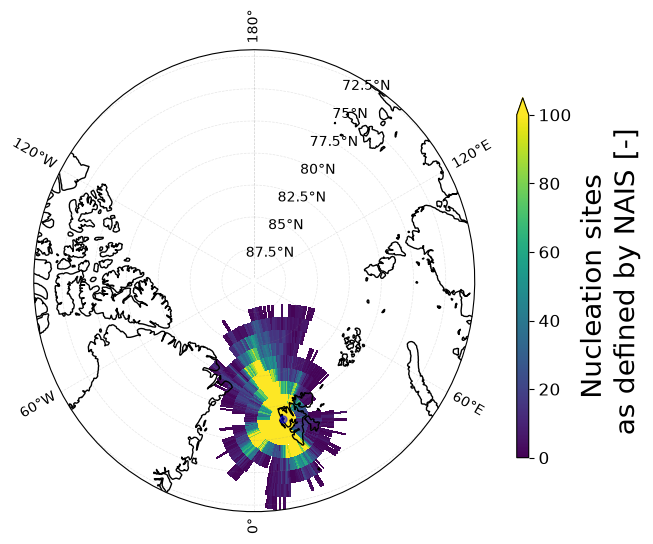

In [22]:
fig = circular_plots_array(count_obs_array, vmax=100, cmap='viridis', 
               orientation='vertical', colourbar_label="Nucleation sites\n as defined by NAIS [-]", 
               colourbar_labelsize=20, colourbar_tick_fontsize=12, decimal_places_colourbar=0, 
               scientific_notation=False, axes_projection='North_Stereo', array_projection='rotated_pole', title='',
                                 lat_min=72)

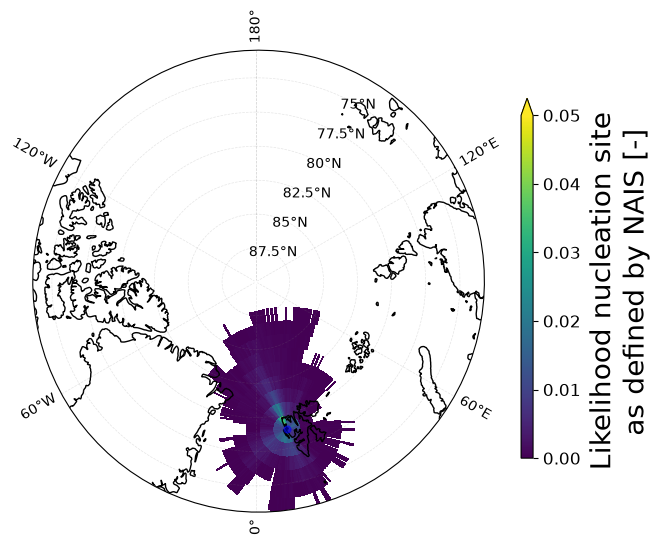

In [23]:
max_value = np.nanmax(count_obs_array)
norm_count_obs_array = count_obs_array/max_value
norm_count_obs_array[norm_count_obs_array == 0] = np.nan

fig = circular_plots_array(norm_count_obs_array, vmax=.05, cmap='viridis', 
               orientation='vertical', colourbar_label="Likelihood nucleation site \n as defined by NAIS [-]", 
               colourbar_labelsize=20, colourbar_tick_fontsize=12, decimal_places_colourbar=2, 
               scientific_notation=False, axes_projection='North_Stereo', array_projection='rotated_pole', title='',
                                 lat_min=73)

In [24]:
def plot_array_rec(array, cmap='Blues', 
    orientation='vertical',
    colourbar_label="Nucleation sites\n as defined by NAIS [-]",
    colourbar_labelsize=20,
    colourbar_tick_fontsize=12,
    decimal_places_colourbar=0, 
    scientific_notation=False,
    axes_projection='North_Stereo',
    array_projection='rotated_pole',
    title='',
    plot_log = False,
    vmin=0,
    vmax=1000,
    ZEP_lon=11.888,
    ZEP_lat=78.906,
    extend = 'max'):

    dict_projections = create_projections_dict(ZEP_lat=78.906,ZEP_lon=11.888, central_longitude=11.888)                   
    projection = dict_projections[axes_projection] 
    array_projection = dict_projections[array_projection] 
            
    fig = plt.figure(figsize=[6,6])

    ax = plt.axes(projection=ccrs.NorthPolarStereo())
    
    lons = np.arange(-178.5, 181.5, 1) #lons = np.arange(-180.5, 179.5, 1)    
    lats = np.arange(1.5, 91.5, 1) #lats = np.arange(-0.5, 89.5, 1)    

    if plot_log == False:
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, 
                        vmin=vmin, vmax=vmax, cmap=cmocean.cm.thermal) 

    if plot_log == True:
        norm=mpl.colors.LogNorm(vmin=vminlog, vmax=vmaxlog)
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, norm=norm, cmap=cmap) 

    geo = ccrs.Geodetic()
    ax.plot([ZEP_lon], [ZEP_lat], 'ro', ms=5, alpha=0.5, transform=geo) 

    if orientation =='horizontal':
        cax = fig.add_axes([0.15, .08, 0.72, 0.03]) # position of colorbar [left, bottom, width, height]
    if orientation =='vertical':
        cax = fig.add_axes([0.75, .2, 0.02, 0.6]) # position of colorbar [left, bottom, width, height]

    kwargs = {'format': '%.'+str(2)+'f'}
    cbar = fig.colorbar(cs, extend='max', orientation='vertical', cax=cax, **kwargs)        
    cbar.set_label('Nucleation sites as defined by NAIS [-]', size=15)
    cbar.ax.tick_params(labelsize=15)

    ax.set_title(str(title), loc='left', size=15)  

    ax.coastlines(resolution='50m')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.2, linestyle='--')

    lat_lims = [70,90]
    ax.set_extent([-10, 20, lat_lims[0], lat_lims[1]], ccrs.PlateCarree())

    plt.show()
    return fig

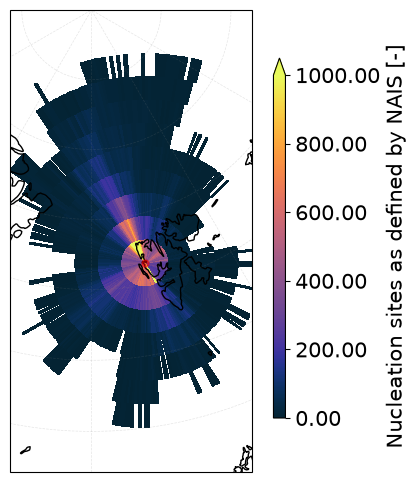

In [25]:
fig = plot_array_rec(count_obs_array)

In [ ]:
def nucleation_figure(array, array_projection='rotated_pole', orientation='horizontal', cmap=cmocean.cm.thermal, ZEP_lon=11.888, ZEP_lat=78.906,
                    plot_log=True, vmaxlog=10**(3), vminlog=10**(-1), vmin=0, vmax=1000, title=''):
    dict_projections = create_projections_dict(ZEP_lat=78.906,ZEP_lon=11.888, central_longitude=11.888)  

    fig = plt.figure(figsize=(6,6))

    lons = np.arange(-178.5, 181.5, 1)   
    lats = np.arange(1.5, 91.5, 1)

    ax = fig.add_subplot(111, projection=ccrs.NorthPolarStereo(central_longitude=12))

    ax.set_extent((0, 359, 80, 90), crs=ccrs.PlateCarree())
    circle_for_polar_map_zep(ax, ZEP_lon)
    array_projection = dict_projections['rotated_pole']
    if plot_log == False:
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, 
                        vmin=vmin, vmax=vmax, cmap=cmocean.cm.thermal, alpha=.5) 
    if plot_log == True:
        norm=mpl.colors.LogNorm(vmin=vminlog, vmax=vmaxlog)
        cs = ax.pcolormesh(lons, lats, array, shading='auto', transform=array_projection, norm=norm, cmap=cmap,
                        alpha=.5) 
    ax.add_feature(cartopy.feature.LAND)
    land = ax.add_feature(cartopy.feature.NaturalEarthFeature('physical', 'land', '10m',linewidth=1, edgecolor='black', facecolor='None'))

    geo = ccrs.Geodetic()
    ax.plot([ZEP_lon], [ZEP_lat], 'ro', ms=5, alpha=0.5, transform=geo) 
    if orientation =='horizontal':
        cax = fig.add_axes([0.15, -.6, 0.72, 0.03]) # position of colorbar [left, bottom, width, height]
    if orientation =='vertical':
        cax = fig.add_axes([0.75, .2, 0.02, 0.6]) # position of colorbar [left, bottom, width, height]

    kwargs = {'format': '%.'+str(2)+'f'}
    cbar = fig.colorbar(cs, extend='max', orientation=orientation, cax=cax, **kwargs)        
    cbar.set_label('Nucleation sites as defined by NAIS [-]', size=15)
    cbar.ax.tick_params(labelsize=15)
    
    gd = Geodesic()    
    geoms = [] 
    for radius in [2.5*10**5, 10*10**5]:
        cp = gd.circle(lon=ZEP_lon, lat=ZEP_lat, radius=radius)
        geoms.append(sgeom.Polygon(cp))
    ax.add_geometries(geoms, crs=ccrs.PlateCarree(), edgecolor='k', alpha=.1, linewidth=10)
    
    ax.text(ZEP_lon - .05, ZEP_lat + .05, 
            'ZEP', 
            va='center', 
            ha='right', transform=ccrs.Geodetic(), fontweight='bold')

    million_lat = 74.165468
    million_lon = -14.477801
    million_name='10$^{6}$ km'

    ax.text(million_lon, million_lat, 
            million_name, 
            va='center', 
            ha='right', transform=ccrs.Geodetic(), fontweight='bold')
    return fig

In [38]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Notebooks\Plots\Figure7.jpeg


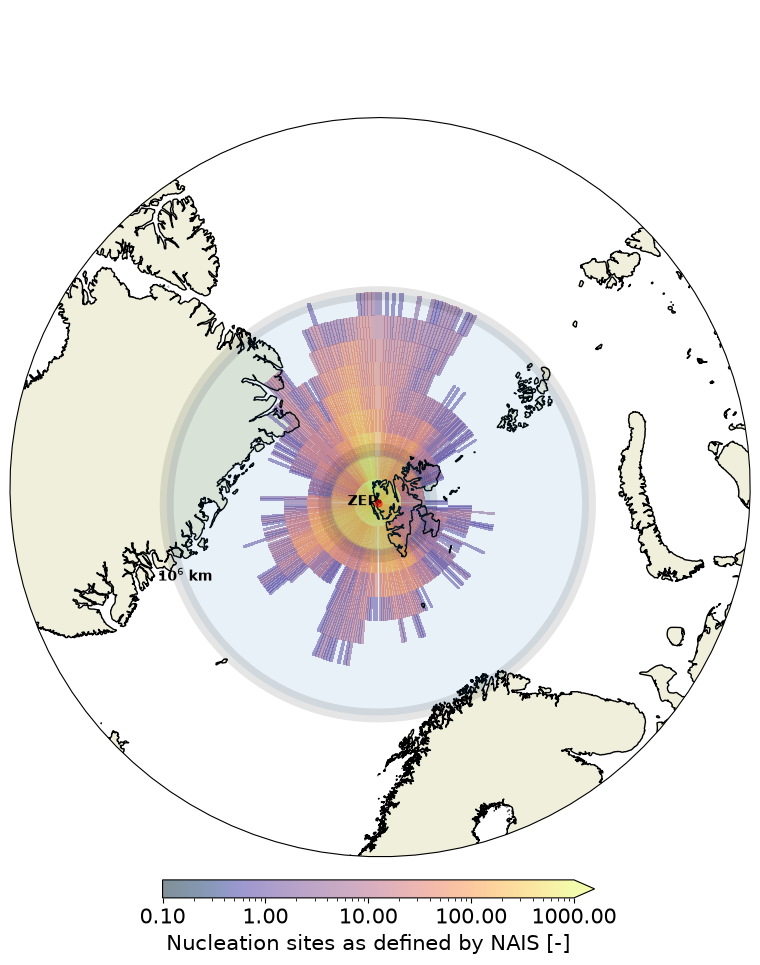

In [39]:
fig = nucleation_figure(count_obs_array, array_projection='rotated_pole', orientation='horizontal', cmap=cmocean.cm.thermal, ZEP_lon=11.888, ZEP_lat=78.906,
                    plot_log=True, vmaxlog=10**(3), vminlog=10**(-1), vmin=0, vmax=1000, title='Timestamp method')

output_figure = plots_outpath / 'Figure7.jpeg'
save_plot(fig, output_figure)